In [1]:
import os
import ast
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10})
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
import torch
# Importing neuroimaging package(s)
import pydicom

In [2]:
import sys
sys.path.append('../src/')

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import datasets
import models

In [3]:
dicom_dir = "/cluster/tufts/hugheslab/datasets/RSNA_AT"
labels_df = pd.read_csv(f"{dicom_dir}/train_2024.csv")
print(labels_df.shape)
labels_df.head()


(3147, 15)


,patient_id,bowel_healthy,bowel_injury,extravasation_healthy,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high,any_injury
0,10004,1,0,0,1,0,1,0,1,0,0,0,0,1,1
1,10005,1,0,1,0,1,0,0,1,0,0,1,0,0,0
2,10007,1,0,1,0,1,0,0,1,0,0,1,0,0,0
3,10026,1,0,1,0,1,0,0,1,0,0,1,0,0,0
4,10051,1,0,1,0,1,0,0,1,0,0,0,1,0,1


In [4]:
instance_level_labels_df = pd.read_csv(f"{dicom_dir}/image_level_labels_2024.csv")
instance_level_labels_df = instance_level_labels_df.groupby(["patient_id", "series_id", "instance_number"]).agg(list).reset_index()
print(instance_level_labels_df.shape)
instance_level_labels_df.head()


(15124, 4)


,patient_id,series_id,instance_number,injury_name
0,33,55570,93,[Bowel]
1,33,55570,94,[Bowel]
2,33,55570,95,[Bowel]
3,33,55570,96,[Bowel]
4,33,55570,97,[Bowel]


In [5]:
data = []

for root, dirs, files in os.walk(f"{dicom_dir}/train_images"):
    for file in files:
        
        path = f"{root}/{file}"
        split_path = path.split("/")
        
        patient_id = split_path[-3]
        series_id = split_path[-2]
        instance_number = split_path[-1].split(".")[0]
        
        data.append({
            "patient_id": patient_id,
            "series_id": series_id,
            "instance_number": instance_number,
            "path": path,
        })

data_df = pd.DataFrame(data)
data_df = data_df.astype({"patient_id": "int64", "series_id": "int64", "instance_number": "int64", "path": "str"})
print(data_df.shape)
data_df.head()


(1500653, 4)


,patient_id,series_id,instance_number,path
0,10004,21057,1000,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...
1,10004,21057,1001,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...
2,10004,21057,1002,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...
3,10004,21057,1003,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...
4,10004,21057,1004,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...


In [6]:
merged_df = data_df.merge(instance_level_labels_df, on=["patient_id", "series_id", "instance_number"], how="left", indicator=True)
merged_df["instance_label"] = merged_df.apply(lambda row: 0.0 if row._merge == "left_only" else 1.0, axis=1)
print(merged_df.shape)
merged_df.head()


(1500653, 7)


,patient_id,series_id,instance_number,path,injury_name,_merge,instance_label
0,10004,21057,1000,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...,NaN,left_only,0.0
1,10004,21057,1001,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...,NaN,left_only,0.0
2,10004,21057,1002,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...,NaN,left_only,0.0
3,10004,21057,1003,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...,NaN,left_only,0.0
4,10004,21057,1004,/cluster/tufts/hugheslab/datasets/RSNA_AT/trai...,NaN,left_only,0.0


In [7]:
merged_df = merged_df.sort_values(by=["patient_id", "series_id", "instance_number"], ascending=[True, True, True])
labels_df = merged_df.groupby(["patient_id", "series_id"]).agg(list).reset_index()
print(labels_df.shape)
labels_df.head()


(4711, 7)


,patient_id,series_id,instance_number,path,injury_name,_merge,instance_label
0,19,14374,"[229, 230, 231, 232, 233, 234, 235, 236, 237, ...",[/cluster/tufts/hugheslab/datasets/RSNA_AT/tra...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,26,18881,"[53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 6...",[/cluster/tufts/hugheslab/datasets/RSNA_AT/tra...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,26,41997,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",[/cluster/tufts/hugheslab/datasets/RSNA_AT/tra...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,33,55570,"[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3...",[/cluster/tufts/hugheslab/datasets/RSNA_AT/tra...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,43,24055,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",[/cluster/tufts/hugheslab/datasets/RSNA_AT/tra...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [9]:
numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_AT_numpy"
labels_df["AT"] = labels_df.apply(lambda row: float(any(row.instance_label)), axis=1)
labels_df["path"] = labels_df["series_id"].apply(lambda series_id: f"{numpy_dir}/{series_id}.npz")
#labels_df.to_csv(f"{numpy_dir}/labels.csv", index=False)
print(labels_df.shape)
labels_df.head()


(4711, 8)


,patient_id,series_id,instance_number,path,injury_name,_merge,instance_label,AT
0,19,14374,"[229, 230, 231, 232, 233, 234, 235, 236, 237, ...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
1,26,18881,"[53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 6...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
2,26,41997,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
3,33,55570,"[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.0
4,43,24055,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[left_only, left_only, left_only, left_only, l...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.0


In [10]:
# for row_index, row in grouped_df.iterrows():
#     scan = []
#     for path in row.path:
#         ds = pydicom.dcmread(path)
#         pixel_array = ds.pixel_array.astype(np.float32)
#         slope = float(getattr(ds, "RescaleSlope", 1))
#         intercept = float(getattr(ds, "RescaleIntercept", 0))
#         rescaled = pixel_array * slope + intercept
#         scan.append(rescaled)
#     print(np.expand_dims(np.stack(scan, axis=-1), axis=0).shape)
#     np.savez(f"{numpy_dir}/{row.series_id}.npz", np.expand_dims(np.stack(scan, axis=-1), axis=0))

In [3]:
numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_AT_numpy"
labels_df = pd.read_csv(f"{numpy_dir}/labels.csv")
columns = ["instance_number", "instance_label"]
labels_df[columns] = labels_df[columns].apply(lambda col: col.map(ast.literal_eval))
print(labels_df.shape)
labels_df.head()


(4711, 8)


,patient_id,series_id,instance_number,path,injury_name,_merge,instance_label,AT
0,19,14374,"[229, 230, 231, 232, 233, 234, 235, 236, 237, ...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
1,26,18881,"[53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 6...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
2,26,41997,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
3,33,55570,"[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.0
4,43,24055,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.0


In [15]:
num_lesions = np.zeros(len(labels_df))
lesion_lengths = []

for row_index, row in labels_df.iterrows():
    
    instance_labels = row["instance_label"]
    patience = 3
    
    counter = 0
    last_one = False
    k = patience
    
    for i in range(len(instance_labels)):

        if instance_labels[i] == 1.0:

            counter += 1
            last_one = True

            if k != patience:
                counter += patience - k

            k = patience

        else:  

            if last_one:

                if k > 0:
                    k -= 1
                else:
                    num_lesions[row_index] += 1
                    lesion_lengths.append(counter/len(instance_labels))
                    counter = 0
                    last_one = False
                    k = patience

    if counter > 0:
        num_lesions[row_index] += 1
        lesion_lengths.append(counter/len(instance_labels))
        
print(f"mean: {np.mean(lesion_lengths)}")
print(f"median: {np.median(lesion_lengths)}")


mean: 0.09319245847642876
median: 0.05947955390334572


In [16]:
print(f"{np.mean(lesion_lengths):.3f}")
print(f"{np.min(lesion_lengths):.3f}")
for q in np.quantile(lesion_lengths, [0.05, 0.25, 0.50, 0.75, 0.95]):
    print(f"{q:.3f}")
print(f"{np.max(lesion_lengths):.3f}")


0.093
0.001
0.004
0.023
0.059
0.137
0.283
0.499


In [13]:
np.unique(num_lesions, return_counts=True)

(array([0., 1., 2., 3., 4.]), array([4346,  304,   53,    7,    1]))

(41-1727)


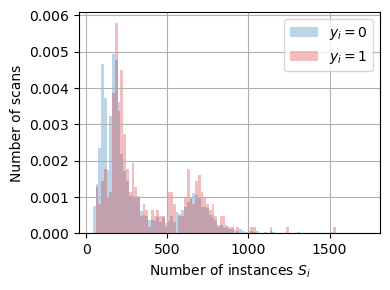

In [82]:
lengths = labels_df.apply(lambda row: len(row.instance_number), axis=1)
print(f"({lengths.min()}-{lengths.max()})")

fig, ax = plt.subplots(1, 1, figsize=(4, 3))

ax.hist(lengths[labels_df.AT == 0.0], alpha=0.3, bins=np.linspace(lengths.min(), lengths.max(), 100), color="#1F77B4", density=True, label=r"$y_i=0$")
ax.hist(lengths[labels_df.AT == 1.0], alpha=0.3, bins=np.linspace(lengths.min(), lengths.max(), 100), color="#D62728", density=True, label=r"$y_i=1$")
ax.set_xlabel(r"Number of instances $S_i$")
ax.set_ylabel("Number of scans")
ax.legend()
ax.grid()

fig.tight_layout()

plt.show()

mean: 0.47955452267148146, std: 0.20526126046668014


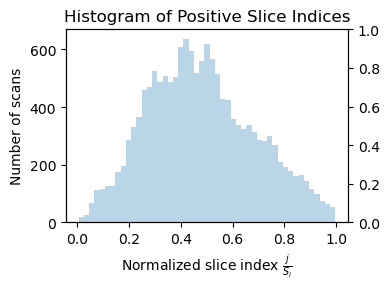

In [84]:
def normal_pdf(x, mu=0.0, sigma=1.0):
    norm_const = 1 / np.sqrt(2.0 * np.pi * sigma**2)
    exp_quad_term = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return norm_const * exp_quad_term

series = labels_df.apply(lambda row: [j / len(row.instance_label) for j, y_ij in enumerate(row.instance_label) if y_ij == 1.0], axis=1)
values = [item for sublist in series for item in sublist]
mean, std = np.mean(values), np.std(values)
print(f"mean: {mean}, std: {std}")

fig, ax1 = plt.subplots(1, 1, figsize=(4, 3))

ax1.hist(values, alpha=0.3, bins=np.linspace(start=min(values), stop=max(values), num=50), color="#1F77B4")
ax2 = ax1.twinx()
x = np.linspace(start=0, stop=1, num=1_000)
#ax2.plot(x, normal_pdf(x, mean, std), color="#000000")
ax1.set_title("Histogram of Positive Slice Indices")
ax1.set_xlabel(r"Normalized slice index $\frac{j}{S_i}$")
ax1.set_ylabel("Number of scans")

fig.tight_layout()
plt.show()


(512, 512)


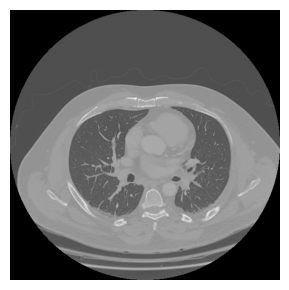

In [15]:
ds = pydicom.dcmread(f"{dicom_dir}/train_images/19/14374/229.dcm")
print(ds.pixel_array.shape)

fig, ax = plt.subplots(1, 1, figsize=(4, 3))

ax.imshow(ds.pixel_array, cmap="gray")
ax.axis("off")

fig.tight_layout()

plt.show()

In [3]:
################################################################################
def print_job(
    alpha, batch_size, criterion, dataset_dir, epochs, embedding_level, 
    experiments_dir, lr, pooling, save, seed, weight_decay
):
    
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"
    
    if os.path.exists(f"{experiments_dir}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{experiments_dir}/{model_name}.csv")
        if temp_df.shape[0] == epochs:
            return
        
    embedding_level = "--embedding_level " if embedding_level else ""
    save = "--save " if save else ""
    
    command = (
        f"python ../src/oasis-3.py "
        f"--alpha={alpha} "
        f"--batch_size={batch_size} "
        f"--criterion=\"{criterion}\" "
        f"--dataset_dir=\"{dataset_dir}\" "
        f"--epochs={epochs} "
        f"{embedding_level}"
        f"--experiments_dir=\"{experiments_dir}\" "
        f"--lr={lr} "
        f"--model_name=\"{model_name}\" "
        f"--pooling=\"{pooling}\" "
        f"{save}"
        f"--seed={seed} "
        f"--weight_decay={weight_decay}"
    )
    
    print(f"    \'{command}\'")

In [4]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
alphas = [0.0001]
beta = 0.0
batch_size = 64
criterions = ["GuidedL1"]
dataset_dir = "/cluster/tufts/hugheslab/datasets/encoded_RSNA_AT/ViT_B_16"
epochs = 1000
embedding_level = True
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_beta=1.0_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_beta2=1.0_embedding_level=True" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_beta=1.0_embedding_level=True_multi_head=False" 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ["Max", "Mean", "ABMIL", "TransMIL", "SmAP"]
poolings = ["SmTAP"]
poolings = ["TransMIL"]
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    temp_dataset_dir = f"{dataset_dir}/seed={seed}"

    print_job(alpha, batch_size, criterion, temp_dataset_dir, epochs, embedding_level, 
              experiments_dir, lr, pooling, save, seed, weight_decay)


    'python ../src/oasis-3.py --alpha=0.0001 --batch_size=64 --criterion="GuidedL1" --dataset_dir="/cluster/tufts/hugheslab/datasets/encoded_RSNA_AT/ViT_B_16/seed=1001" --epochs=1000 --embedding_level --experiments_dir="/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_beta2=1.0_embedding_level=True" --lr=0.1 --model_name="alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling=TransMIL_seed=1001" --pooling="TransMIL" --save --seed=1001 --weight_decay=0.0'
    'python ../src/oasis-3.py --alpha=0.0001 --batch_size=64 --criterion="GuidedL1" --dataset_dir="/cluster/tufts/hugheslab/datasets/encoded_RSNA_AT/ViT_B_16/seed=2001" --epochs=1000 --embedding_level --experiments_dir="/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_beta2=1.0_embedding_level=True" --lr=0.1 --model_name="alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling=TransMIL_seed=2001" --pooling="TransMIL" --save --seed=2001 --weight_decay=0.0'
    'python ../src/oasis-3.py --alpha=0.0001 --batch_size=64 --criterion

In [3]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ["GuidedL1"]
dataset_dir = "/cluster/tufts/hugheslab/datasets/encoded_RSNA_AT/ViT_B_16"
epochs = 1000
embedding_level = True
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_beta=1.0_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_beta2=1.0_embedding_level=True" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_beta=1.0_embedding_level=True_multi_head=False" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_best_possible_instance-level" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/encoded_RSNA_AT_best_possible_bag-level" 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ["SmTAP"]
poolings = ["TransMIL"]
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

columns = ["model_name", "seed", "test_auroc", "test_auprc", "test_bal_acc", "test_loss", "test_nll", "train_auroc", "train_auprc", "train_bal_acc", "train_loss", "train_nll", "val_auroc", "val_auprc", "val_bal_acc", "val_loss", "val_nll"]
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"
    #model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_seed={seed}"
    
    if os.path.exists(f"{experiments_dir}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{experiments_dir}/{model_name}.csv")
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, seed, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(["seed"])["val_auroc"].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,seed,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=0.0001_criterion=GuidedL1_lr=0.01_poolin...,1001,0.752702,0.150285,0.508229,4.639232,0.266116,0.838304,0.421924,0.677548,4.621551,0.237949,0.704487,0.163192,0.522399,4.662316,0.289557
1,alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling...,2001,0.644184,0.142170,0.630326,3.793901,0.843013,0.718198,0.202117,0.603212,3.441192,0.360680,0.656657,0.144577,0.629167,3.730821,0.780270
2,alpha=0.0001_criterion=GuidedL1_lr=0.01_poolin...,3001,0.645991,0.153353,0.555502,4.742267,0.365695,0.856993,0.486828,0.690395,4.594703,0.206869,0.761345,0.167600,0.587480,4.683096,0.305974


In [4]:
print(f"${df.test_auroc.mean():.3f}${{\\tiny$\pm {df.test_auroc.std():.3f}$}}")
print(f"${df.test_auprc.mean():.3f}${{\\tiny$\pm {df.test_auprc.std():.3f}$}}")


$0.681${\tiny$\pm 0.062$}
$0.149${\tiny$\pm 0.006$}


In [5]:
df.model_name.values

array(['alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=TransMIL_seed=1001',
       'alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling=TransMIL_seed=2001',
       'alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=TransMIL_seed=3001'],
      dtype=object)

In [6]:
numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_AT_numpy"
labels_df = pd.read_csv(f"{numpy_dir}/labels.csv")
columns = ["instance_number", "instance_label"]
labels_df[columns] = labels_df[columns].apply(lambda col: col.map(ast.literal_eval))
print(labels_df.shape)
labels_df.head()


(4711, 8)


,patient_id,series_id,instance_number,path,injury_name,_merge,instance_label,AT
0,19,14374,"[229, 230, 231, 232, 233, 234, 235, 236, 237, ...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
1,26,18881,"[53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 6...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
2,26,41997,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
3,33,55570,"[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.0
4,43,24055,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",/cluster/tufts/hugheslab/datasets/RSNA_AT_nump...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","['left_only', 'left_only', 'left_only', 'left_...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.0


In [13]:
seed = 3001

grouped_df = labels_df.groupby("patient_id")["AT"].agg(lambda x: x.mode()[0]).reset_index()
ids, id_labels = grouped_df["patient_id"], grouped_df["AT"]
train_and_val_ids, test_ids, train_and_val_id_labels, test_id_labels = train_test_split(ids, id_labels, test_size=1/6, random_state=seed, stratify=id_labels)
train_ids, val_ids = train_test_split(train_and_val_ids, test_size=1/5, random_state=seed, stratify=train_and_val_id_labels)

train_df = labels_df[labels_df["patient_id"].isin(train_ids)]
val_df = labels_df[labels_df["patient_id"].isin(val_ids)]
test_df = labels_df[labels_df["patient_id"].isin(test_ids)]

dataset_dir = f"/cluster/tufts/hugheslab/datasets/encoded_RSNA_AT/ViT_B_16/seed={seed}"

train_data = torch.load(f"{dataset_dir}/train.pt", map_location=torch.device("cpu"))
val_data = torch.load(f"{dataset_dir}/val.pt", map_location=torch.device("cpu"))
test_data = torch.load(f"{dataset_dir}/test.pt", map_location=torch.device("cpu"))

train_dataset = datasets.MILTensorDataset(train_data["X"], train_data["lengths"], train_data["y"])
val_dataset = datasets.MILTensorDataset(val_data["X"], val_data["lengths"], val_data["y"])
test_dataset = datasets.MILTensorDataset(test_data["X"], test_data["lengths"], test_data["y"])


In [14]:
#model = models.PoolClf(in_features=768, out_features=1, pooling="ABMIL")
#model = models.PoolClf(in_features=768, out_features=1, pooling="SmAP")
model = models.PoolClf(in_features=768, out_features=1, pooling="TransMIL")
#model = models.PoolClf(in_features=768, out_features=1, pooling="SmTAP")
#model = models.InstanceLevelClassifier(in_features=768, out_features=1, kernel_size=29)

experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_embedding_level=True"
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_beta=1.0_embedding_level=True"
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_beta2=1.0_embedding_level=True"
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_AT_best_possible_instance-level"

#model_name = "alpha=0.001_criterion=L1_lr=0.1_pooling=ABMIL_seed=1001"
#model_name = "alpha=0.001_criterion=L1_lr=0.1_pooling=ABMIL_seed=2001"
#model_name = "alpha=0.001_criterion=L1_lr=0.01_pooling=ABMIL_seed=3001"
#model_name = "alpha=0.001_criterion=L1_lr=0.01_pooling=SmAP_seed=1001"
#model_name = "alpha=0.001_criterion=L1_lr=0.01_pooling=SmAP_seed=2001"
#model_name = "alpha=0.0001_criterion=L1_lr=0.01_pooling=SmAP_seed=3001"
model_name = "alpha=0.001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=1001"
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling=ABMIL_seed=2001"
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling=ABMIL_seed=3001"
#model_name = "alpha=0.0001_criterion=L1_lr=0.01_pooling=TransMIL_seed=1001"
#model_name = "alpha=0.0001_criterion=L1_lr=0.1_pooling=TransMIL_seed=2001"
#model_name = "alpha=0.0001_criterion=L1_lr=0.01_pooling=TransMIL_seed=3001"
model_name = "alpha=0.0001_criterion=L1_lr=0.01_pooling=SmTAP_seed=1001"
model_name = "alpha=0.0001_criterion=L1_lr=0.1_pooling=SmTAP_seed=2001"
model_name = "alpha=0.0001_criterion=L1_lr=0.01_pooling=SmTAP_seed=3001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=TransMIL_seed=1001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling=TransMIL_seed=2001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=TransMIL_seed=3001"

#model_name = "alpha=0.0_criterion=L1_lr=0.1_seed=1001"
#model_name = "alpha=0.0_criterion=L1_lr=0.1_seed=2001"
#model_name = "alpha=0.0_criterion=L1_lr=0.1_seed=3001"

model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=TransMIL_seed=1001"
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling=TransMIL_seed=2001"
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=TransMIL_seed=3001"

checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

model.load_state_dict(checkpoint)

attn_corrs = []
aurocs = []
auprcs = []

with torch.no_grad():
    
    for i in range(len(test_dataset)):
        h_i, S_i, y_i = test_dataset[i]
        y_ij = test_data["lengths_y"][i]

        if y_i == 1.0:
            #x = torch.arange(start=1, end=S_i + 1)
            #a_i = utils.normal_pdf(x, mu=S_i / 2, sigma=1.0)
            #a_i = a_i / a_i.sum()
            #a_i = torch.stack([torch.sum(torch.argmax(h_i, dim=0, keepdim=True) == j) / h_i.shape[1] for j in range(S_i)]).unsqueeze(1)
            #a_i = np.ones_like(y_ij) / S_i
            _, a_i = model(h_i, (S_i,))
            a_i = torch.mean(a_i, dim=1).detach()
            attn_corrs.append(a_i[np.array(y_ij) == 1.0].sum())
            aurocs.append(roc_auc_score(y_ij, a_i))
            auprcs.append(average_precision_score(y_ij, a_i))


In [15]:
print(np.mean(attn_corrs))
print(np.mean(aurocs))
print(np.mean(auprcs))

0.14311285
0.6447230038593662
0.23327471654879714


In [17]:
guided2_transmil_aurocs = [0.6340763504825431, 0.6440076670442785, 0.6447230038593662]
guided2_transmil_auprcs = [0.23246859179173315, 0.21954519968466887, 0.23327471654879714]
print(f"${np.mean(guided2_transmil_aurocs):.3f}${{\\tiny$\pm {np.std(guided2_transmil_aurocs):.3f}$}}")
print(f"${np.mean(guided2_transmil_auprcs):.3f}${{\\tiny$\pm {np.std(guided2_transmil_auprcs):.3f}$}}")


$0.641${\tiny$\pm 0.005$}
$0.228${\tiny$\pm 0.006$}


In [17]:
smtap_aurocs = [0.5811898498487557, 0.6353806342044785, 0.5295937165474177]
smtap_auprcs = [0.19497336875794938, 0.24286213990220848, 0.14792340646125163]
print(f"${np.mean(smtap_auprcs):.3f}${{\\tiny$\pm {np.std(smtap_auprcs):.3f}$}}")


$0.195${\tiny$\pm 0.039$}


In [98]:
guided_transmil_aurocs = [0.632047255420571, 0.6522157133605336, 0.6263276622448146]
guided_transmil_auprcs = [0.24061626005487535, 0.21396237031095136, 0.21969608247398104]
print(f"${np.mean(auprcs):.3f}${{\\tiny$\pm {np.std(auprcs):.3f}$}}")


$0.227${\tiny$\pm 0.010$}


In [7]:
gaussian_attn_corr = [0.22945293996003804, 0.2392907457817832, 0.14677647858712406]
max_attn_corr = [0.083077565, 0.091008775, 0.08950772]
mean_attn_corr = [0.09589822400543978, 0.1120814389928889, 0.10331615505112965]
abmil_attn_corr = [0.095898084, 0.11208125, 0.10333197]
smap_attn_corr = [0.10439287, 0.13130014, 0.10530496]
guided_abmil_attn_corr = [0.14129004, 0.1583558, 0.1457582]
transmil_attn_corr = [0.10413958, 0.09786635, 0.10202821]
best_attn_corr = [0.21548216, 0.2546826, 0.17762753]
print(f"${np.mean(max_attn_corr):.3f}${{\\tiny$\pm {np.std(max_attn_corr):.3f}$}}")


$0.088${\tiny$\pm 0.003$}


In [8]:
gaussian_aurocs = [0.570890298081632, 0.6124221307377097, 0.535774126086394]
max_aurocs = [0.4553562213117109, 0.43950621805461865, 0.465079221309069]
mean_aurocs = [0.5, 0.5, 0.5]
abmil_aurocs = [0.5331020417174118, 0.4721475402217424, 0.5727915249737253]
smap_aurocs = [0.5807618319928464, 0.5524476094083864, 0.5596502456947363]
guided_abmil_aurocs = [0.6536637209280899, 0.6684871716499551, 0.6657328405913262]
transmil_aurocs = [0.5950357693234992, 0.6064284610390231, 0.5347931925107201]
best_aurocs = [0.7071436492816802, 0.7326451019297682, 0.7112536689809308]
print(f"${np.mean(max_aurocs):.3f}${{\\tiny$\pm {np.std(max_aurocs):.3f}$}}")


$0.453${\tiny$\pm 0.011$}


In [9]:
gaussian_auprcs = [0.24715836118498982, 0.2507428751259972, 0.16939516205982053]
max_auprcs = [0.10592979271474719, 0.10873217699986687, 0.11112409659165891]
mean_auprcs = [0.09589822400543979, 0.11208143899288892, 0.10331615505112965]
abmil_auprcs = [0.15863822842093156, 0.1262784478630111, 0.193159447992102]
smap_auprcs = [0.1494940994675449, 0.19546237232024644, 0.1568012776562291]
guided_abmil_auprcs = [0.2631638111020191, 0.2197594682177364, 0.2617079993900664]
transmil_auprcs = [0.19684304410113995, 0.21306565421179072, 0.16241812888520468]
best_auprcs = [0.2760778176764355, 0.3256903071187709, 0.2536189178554547]
print(f"${np.mean(max_auprcs):.3f}${{\\tiny$\pm {np.std(max_auprcs):.3f}$}}")


$0.109${\tiny$\pm 0.002$}
